# DS 542 Spring 2026 Project 1

In this class, projects are basically longer (e.g. 2-week) homework assignments here you are expected to do more experimentation and coding.

* Your task for this project is to improve the training results for a fixed architecture model for the Tree-or-Not data set.
* Your model will be constrained to use the architecture in this template.
* To train a better model, you will instead explore picking appropriate early stopping rules, initialization, learning rate, regularization and data augmentation.


## Background

This notebook builds a model detecting trees in images.
The data set is available on GitHub at https://github.com/DL4DS/tree-or-not or on the Shared Compute Cluster at `/projectnb/dl4ds/materials/datasets/tree-or-not`.

The initial data set consists of about 500 pictures. Most of them are from the Boston area, but some are from around the globe. Most of them were taken outside, but some were taken inside or in more exotic locations. Many other factors such as lighting, weather, and confounding bushes will make this a challenging problem.

## Assignment Directions

1. Run the provided notebook and confirm basic functionality.
2. Inspect the dataset. Do you see any labeling errors? (5%)
2. Explore training improvements in each of the following categories and report the results - early stopping, initialization, learning rate, regularization and data augmentation. (25%)
3. Take the best configuration of each of the five training modifications and apply them all to see what overall improvement you can get. (30%)
4. Explain as best you can why each improvement was included or not included in the best performing model. (10%)
5. Save the best performing model for further evaluation by the auto-grader. (30%)


## Modules

In [1]:
import imageio.v2 as imageio
import livelossplot
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torcheval.metrics

## GPU Access

In [2]:
def to_gpu(t):
    if torch.cuda.is_available():
        return t.cuda()
    return t

def to_numpy(t):
    return t.detach().cpu().numpy()

device = to_gpu(torch.ones(1,1)).device
device

device(type='cuda', index=0)

## Load Data

If you are not running on the SCC, fetch the data from https://github.com/dl4ds/tree-or-not as needed. For example, you could use `git clone` to make a local copy and update `data_dir` below.

If you are running on SCC, the data is already loaded so just leave `data_dir` as is.

In [59]:
# If you are running locally, change this path to the local path of the tree-or-not data set.
data_dir = "/projectnb/dl4ds/materials/datasets/tree-or-not"

In [4]:
# DO NOT CHANGE THIS CELL

image_width = 256

def load_data_set(data_set_name):
    labels = pd.read_csv(f"{data_dir}/{data_set_name}.tsv", sep="\t")

    file_names = []
    images = []
    targets = []
    for i in range(labels.shape[0]):
        row = labels.iloc[i]
        try:
            image = imageio.imread(f"{data_dir}/images{image_width}/{row['filename']}")[...]
        except:
            print("SKIPPING ", row['filename'], "MISSING")
            continue

        if image.shape[0] != image.shape[1] * 3 // 4:
            print("SKIPPING ", row['filename'], image.shape)
            continue

        # convert from 0-255 to 0.0-1.0
        image = image / 255
        # prepend axis with length one
        # image = image.reshape(1, *image.shape)
        image = torch.tensor(image, device=device, dtype=torch.float32)
        # permute image dimensions to put color channel first
        image = torch.permute(image, [2, 0, 1])

        file_names.append(row['filename'])
        images.append(image)
        targets.append(row["target"])

    images = torch.stack(images)

    targets = torch.tensor(targets, device=device, dtype=torch.float32)
    targets = targets.long()

    return (file_names, images, targets)

train_data_set = load_data_set("train")
for t in train_data_set[1:]:
    print("TRAIN", t.shape, t.dtype, t.device)
(train_file_names, train_X, train_Y) = train_data_set

validation_data_set = load_data_set("validation")
for t in validation_data_set[1:]:
    print("VALIDATION", t.shape, t.dtype, t.device)
(validation_file_names, validation_X, validation_Y) = validation_data_set

validation2_data_set = load_data_set("validation2")
for t in validation2_data_set[1:]:
    print("VALIDATION2", t.shape, t.dtype, t.device)
(validation2_file_names, validation2_X, validation2_Y) = validation2_data_set

TRAIN torch.Size([292, 3, 192, 256]) torch.float32 cuda:0
TRAIN torch.Size([292]) torch.int64 cuda:0
VALIDATION torch.Size([97, 3, 192, 256]) torch.float32 cuda:0
VALIDATION torch.Size([97]) torch.int64 cuda:0
SKIPPING  IMG_1585.png (256, 192, 3)
VALIDATION2 torch.Size([108, 3, 192, 256]) torch.float32 cuda:0
VALIDATION2 torch.Size([108]) torch.int64 cuda:0


tensor([[[[0.6275, 0.3176, 0.1922,  ..., 0.6902, 0.3373, 0.2314],
          [0.5804, 0.2549, 0.3137,  ..., 0.5686, 0.4078, 0.5765],
          [0.4902, 0.4118, 0.5059,  ..., 0.4078, 0.5373, 0.7412],
          ...,
          [0.5216, 0.6118, 0.6588,  ..., 0.4863, 0.5098, 0.5216],
          [0.5333, 0.5333, 0.4745,  ..., 0.5804, 0.5922, 0.6118],
          [0.6157, 0.6039, 0.6157,  ..., 0.5843, 0.5882, 0.6196]],

         [[0.6353, 0.3765, 0.2588,  ..., 0.6314, 0.3490, 0.2667],
          [0.6471, 0.3333, 0.3647,  ..., 0.5608, 0.4235, 0.5765],
          [0.5608, 0.4510, 0.5529,  ..., 0.4353, 0.5412, 0.7176],
          ...,
          [0.4902, 0.5725, 0.6196,  ..., 0.4902, 0.5137, 0.5216],
          [0.5020, 0.4980, 0.4431,  ..., 0.5765, 0.5882, 0.6000],
          [0.5608, 0.5608, 0.5765,  ..., 0.5804, 0.5843, 0.6196]],

         [[0.5059, 0.2000, 0.0078,  ..., 0.2745, 0.1020, 0.0471],
          [0.1647, 0.1569, 0.0627,  ..., 0.2588, 0.1647, 0.1725],
          [0.0118, 0.1451, 0.1804,  ..., 0

## Inspect the Data Set

This is a handy way to inspect the dataset. Randomly choose 4 images at a time.

It is a common oversight to not look closely at the dataset. It's often worthwhile to ensure everything is labeled correctly.

### Inspect the training set

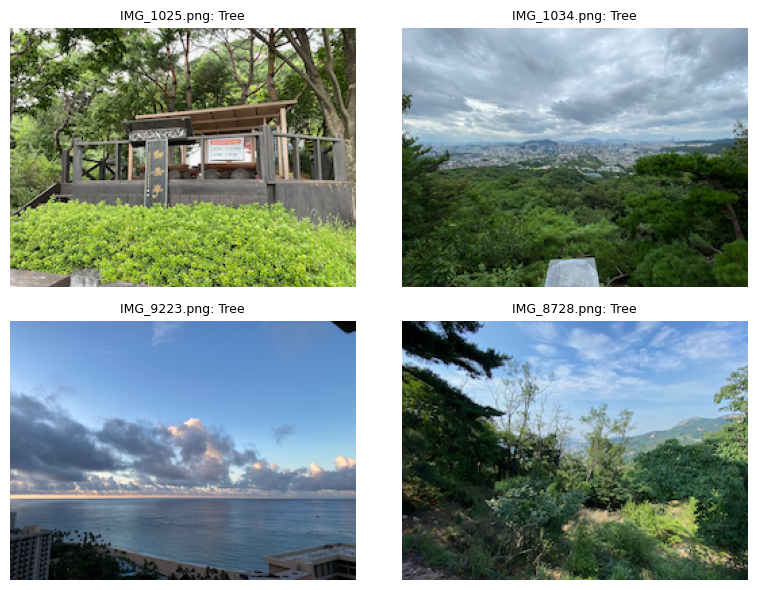

In [5]:
# You can rerun this cell to randomly inspect different images.

idx = torch.randperm(train_X.shape[0])[:4]
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

label_names = {0: "Not Tree", 1: "Tree"}

for ax, i in zip(axes.flatten(), idx):
    ax.imshow(to_numpy(torch.permute(train_X[i, :, :, :], (1, 2, 0))))
    label = label_names.get(int(train_Y[i]), str(int(train_Y[i])))
    ax.set_title(f"{train_file_names[int(i)]}: {label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()

### Inspect the validation set

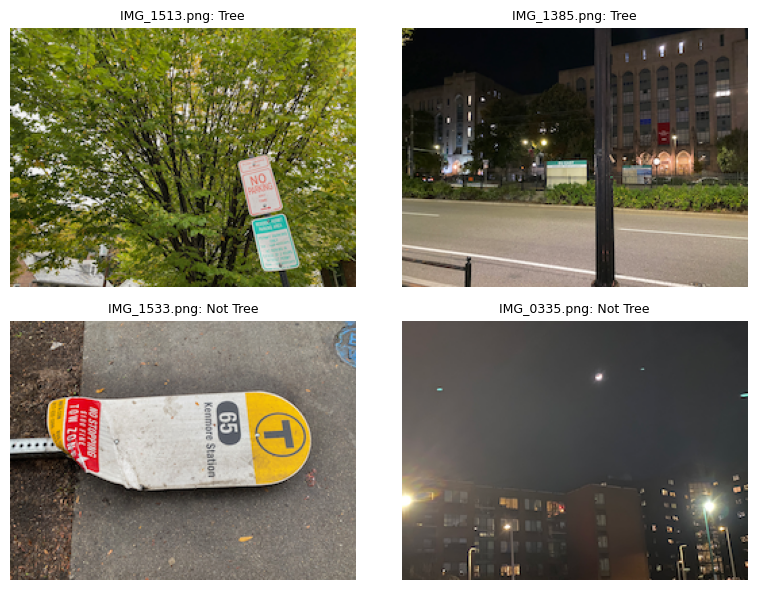

In [91]:
# You can rerun this cell to randomly inspect different images.

idx = torch.randperm(validation_X.shape[0])[:4]
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

label_names = {0: "Not Tree", 1: "Tree"}

for ax, i in zip(axes.flatten(), idx):
    ax.imshow(to_numpy(torch.permute(validation_X[i, :, :, :], (1, 2, 0))))
    label = label_names.get(int(validation_Y[i]), str(int(validation_Y[i])))
    ax.set_title(f"{validation_file_names[int(i)]}: {label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()

### Inspect the 2nd Validation Set

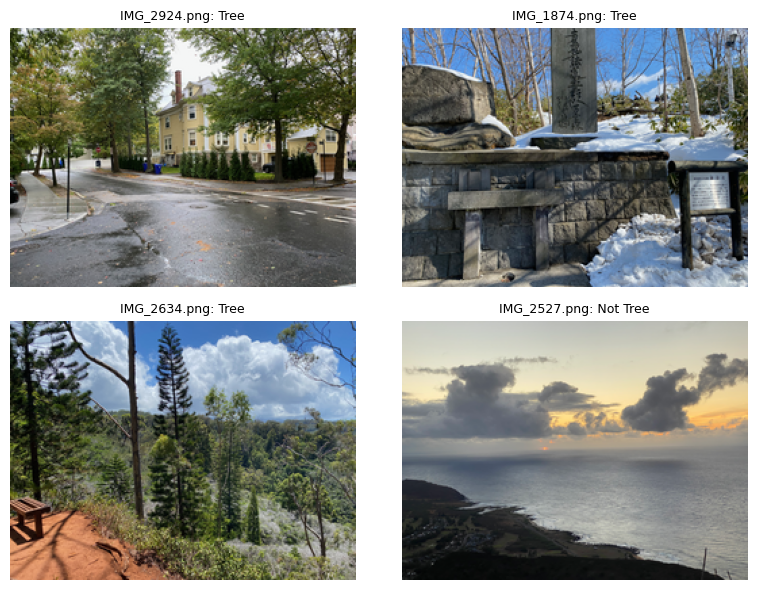

In [7]:
# You can rerun this cell to randomly inspect different images.

idx = torch.randperm(validation2_X.shape[0])[:4]
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

label_names = {0: "Not Tree", 1: "Tree"}

for ax, i in zip(axes.flatten(), idx):
    ax.imshow(to_numpy(torch.permute(validation2_X[i, :, :, :], (1, 2, 0))))
    label = label_names.get(int(validation2_Y[i]), str(int(validation2_Y[i])))
    ax.set_title(f"{validation2_file_names[int(i)]}: {label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()

<!-- BEGIN QUESTION -->

## Dataset Evaluation (5%)

What is your assessment of the dataset? Are all the images labeled well? Do you see any anomolies? If so, list the image names and what you think the labels should be.

Overall, the dataset is properly labelled. There are a few anomalies. For instance, IMG_1619 contains an overview shot of Commonwealth Avenue from the CDS building. If one inspects closely, they could actually see some trees but they are very small and may even be challenging for a human annotator to extract. I do think overall the dataset is properly labelled. Even in cases where there are grass, plants, flowers, the labels are properly labelled as not tree. Additionally, IMG_1523 looks like it could be a very small tree because there are branches and leaves; iI can get how the models could get confused and label it is a tree.

<!-- END QUESTION -->

## Model Building

> Do not modify the architecture of the network. You can add regularizations that apply during training but don't effect the architecture.

In [10]:
DEFAULT_EPOCHS=500
class TreeNetwork(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_0 = torch.nn.Conv2d(in_channels=3, out_channels=5, kernel_size=5, stride=2, device=device)
        self.conv_1 = torch.nn.Conv2d(in_channels=5, out_channels=5, kernel_size=5, stride=2, device=device)
        self.conv_2 = torch.nn.Conv2d(in_channels=5, out_channels=5, kernel_size=5, stride=2, device=device)
        self.conv_3 = torch.nn.Conv2d(in_channels=5, out_channels=5, kernel_size=5, stride=2, device=device)
        self.fc_3 = torch.nn.Linear(585, 2)

        self.relu = torch.nn.ReLU()

    def forward(self, X):

        X = self.conv_0(X)
        X = self.relu(X)

        X = self.conv_1(X)
        X = self.relu(X)

        X = self.conv_2(X)
        X = self.relu(X)

        X = self.conv_3(X)
        X = self.relu(X)

        # flatten channels and image dimensions
        X = X.reshape(X.shape[:-3] + (-1,))

        X = self.fc_3(X)

        return X

test_model = TreeNetwork().to(device)
test_output = test_model(train_X[:5,:,:,:])
assert test_output.shape == (5, 2)
del test_output

In [7]:
loss_function = torch.nn.CrossEntropyLoss()

In [55]:
DEFAULT_EPOCHS = 500

def train_model(model_class, epochs=DEFAULT_EPOCHS, learning_rate=1e-4, **kwargs):
    """
    Train a model for a given number of epochs and plot the loss and accuracy for the training and validation sets.
    """
    model = model_class(**kwargs)
    if torch.cuda.is_available():
        model = model.cuda()

    model = torch.nn.DataParallel(model)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    liveloss = livelossplot.PlotLosses()
    for i in range(epochs):
        model.train()

        optimizer.zero_grad(set_to_none=True)
        prediction = model(train_X)
        loss = loss_function(prediction, train_Y)
        loss.backward()
        optimizer.step()

        if (i + 1) % 50 == 0:
            liveloss_updates = {}
            with torch.no_grad():
                model.eval()

                def get_metrics(metrics_prefix, metrics_X, metrics_Y):
                    metrics_prediction = model(metrics_X)

                    return {
                        f"{metrics_prefix}loss": loss_function(metrics_prediction, metrics_Y),
                        f"{metrics_prefix}accuracy": torcheval.metrics.functional.multiclass_accuracy(torch.argmax(metrics_prediction, dim=-1), metrics_Y)
                    }
                
                liveloss_updates.update(get_metrics("", train_X, train_Y))
                liveloss_updates.update(get_metrics("val_", validation_X, validation_Y))

            liveloss_updates = {k: to_numpy(v) for k, v in liveloss_updates.items()}
            liveloss.update(liveloss_updates,
                            current_step=i+1)
            liveloss.send()

    return model

# We use a fixed seed for reproducibility
torch.manual_seed(42)

test_model = train_model(TreeNetwork, epochs=1)
del test_model

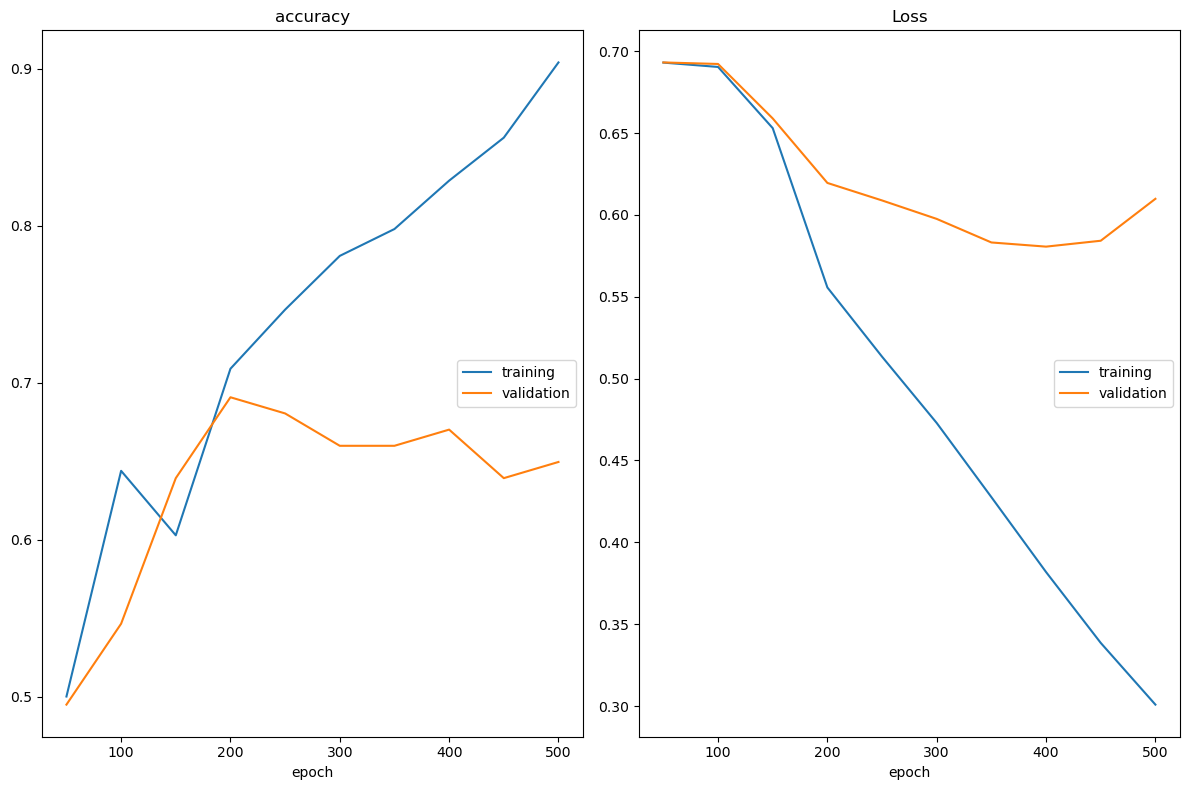

accuracy
	training         	 (min:    0.500, max:    0.904, cur:    0.904)
	validation       	 (min:    0.495, max:    0.691, cur:    0.649)
Loss
	training         	 (min:    0.301, max:    0.693, cur:    0.301)
	validation       	 (min:    0.581, max:    0.693, cur:    0.610)


In [56]:
base_model = train_model(TreeNetwork, epochs=DEFAULT_EPOCHS)

## Training Improvements (25%)

In this section you will experiment with five different kinds of training improvements:
1. Early stopping
3. Initialization
4. Learning Rates
5. Regularization
6. Data Augmentation

**Your description must be specific to this data set and baseline training process.**

You do not need to describe how these methods work in general, and generalities may cost points for making your answer less concise.

You can train your models below with a different number of epochs than used above.

Warning:
Your training improvements will be sanity checked when models are built with them below.

If your training improvement does not improve the validation accuracy, then it will deemed inappropriate for this specific data set and architecture, and you will lose points here.

<!-- BEGIN QUESTION -->

### Early Stopping (5% of the 25%)

The baseline model overfits a lot.

Update the training strategy to implement early stopping to avoid entering the overfitting regime. There are multiple ways to do this.

In [12]:
# Notes from Stanley: 
## A few ideas: 
## Implement early stopping when validation set stops improving after a number of epoch. 
## The idea is that we have a patience counter which means we can be patient for an X number of epoch if loss does not improve
## Another idea is that we are given two validation dataset, 

In [90]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.
import os

class EarlyStopping: 
    def __init__(self, patience: int, metric: str = "loss", tolerance: torch.Tensor = torch.Tensor([1e-3])): 
        self.patience = patience
        self.current_counter = 0
        self.metric = metric
        self.should_stop = False 
        self.tolerance = to_gpu(tolerance)
        self._set_trend()
        self._initialize_best_metric()
        
    def _set_trend(self): 
        ## Basically if metric is accurracy it should trend up or if metric is loss then it should trend down
        if self.metric == "accuracy": 
            self.trend = True
        elif self.metric == "loss": 
            self.trend = False
        else: 
            raise ValueError("Metric is not accuracy or loss")
            
    def _initialize_best_metric(self):
        if self.trend:  # accuracy
            self.best_metric = to_gpu(torch.Tensor([-float("inf")]))
        else:  # loss
            self.best_metric = to_gpu(torch.Tensor([float("inf")]))

    def _checkpoint_model(self, model): 
        os.makedirs("chkpt", exist_ok=True) 
        model.eval()
        torch.save(model.state_dict(), 'chkpt/best_model.pth')
        
    def check_metrics(self, current_metric, model): 
        # Determine if improvement happened
        if torch.isclose(current_metric, self.best_metric, rtol=0.01): 
            pass 
        if self.trend:
            improved = current_metric >= (self.best_metric + self.tolerance)
        else:
            improved = current_metric <= (self.best_metric - self.tolerance)

        if improved:
            self.best_metric = current_metric
            self.current_counter = 0
            self._checkpoint_model(model)
        else:
            self.current_counter += 1
            print(f"No significant improvement. Counter: {self.current_counter}")

        if self.current_counter >= self.patience:
            print("Stopping training")
            self.should_stop = True
            return self.should_stop

        return self.should_stop

In [73]:

def train_model_with_intervention_1(
    model_class, 
    patience, 
    eval_metric, 
    epochs=DEFAULT_EPOCHS, 
    tolerance=torch.Tensor([1e-3]),
    check_every=3,
    learning_rate=1e-4, 
    **kwargs
):
    """
    Train a model for a given number of epochs and plot the loss and accuracy for the training and validation sets.
    """
    model = model_class(**kwargs)
    stopper = EarlyStopping(
        patience=patience,
        metric=eval_metric, 
        tolerance=tolerance
    )
        
    if torch.cuda.is_available():
        model = model.cuda()

    model = torch.nn.DataParallel(model)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    liveloss = livelossplot.PlotLosses()

    def get_metrics(metrics_prefix, metrics_X, metrics_Y):
        metrics_prediction = model(metrics_X)

        return {
            f"{metrics_prefix}loss": loss_function(metrics_prediction, metrics_Y),
            f"{metrics_prefix}accuracy": torcheval.metrics.functional.multiclass_accuracy(torch.argmax(metrics_prediction, dim=-1), metrics_Y)
        }
    for i in range(epochs):
        model.train()

        optimizer.zero_grad(set_to_none=True)
        prediction = model(train_X)
        loss = loss_function(prediction, train_Y)
        loss.backward()
        optimizer.step()

        if (i % check_every) == 0: 
            with torch.no_grad(): 
                model.eval()
                val_dict = get_metrics("", validation_X, validation_Y)
                val_metric = val_dict[eval_metric]
                should_stop = stopper.check_metrics(current_metric=val_metric, model=model)
                if should_stop: 
                    break 

        if (i + 1) % 50 == 0:
            liveloss_updates = {}
            with torch.no_grad():
                model.eval()
                
                liveloss_updates.update(get_metrics("", train_X, train_Y))
                liveloss_updates.update(get_metrics("val_", validation_X, validation_Y))

            liveloss_updates = {k: to_numpy(v) for k, v in liveloss_updates.items()}
            liveloss.update(liveloss_updates,
                            current_step=i+1)
            liveloss.send()

    return model

# We use a fixed seed for reproducibility
torch.manual_seed(42)

test_model = train_model_with_intervention_1(TreeNetwork, patience=6, eval_metric="loss", epochs=1)
del test_model

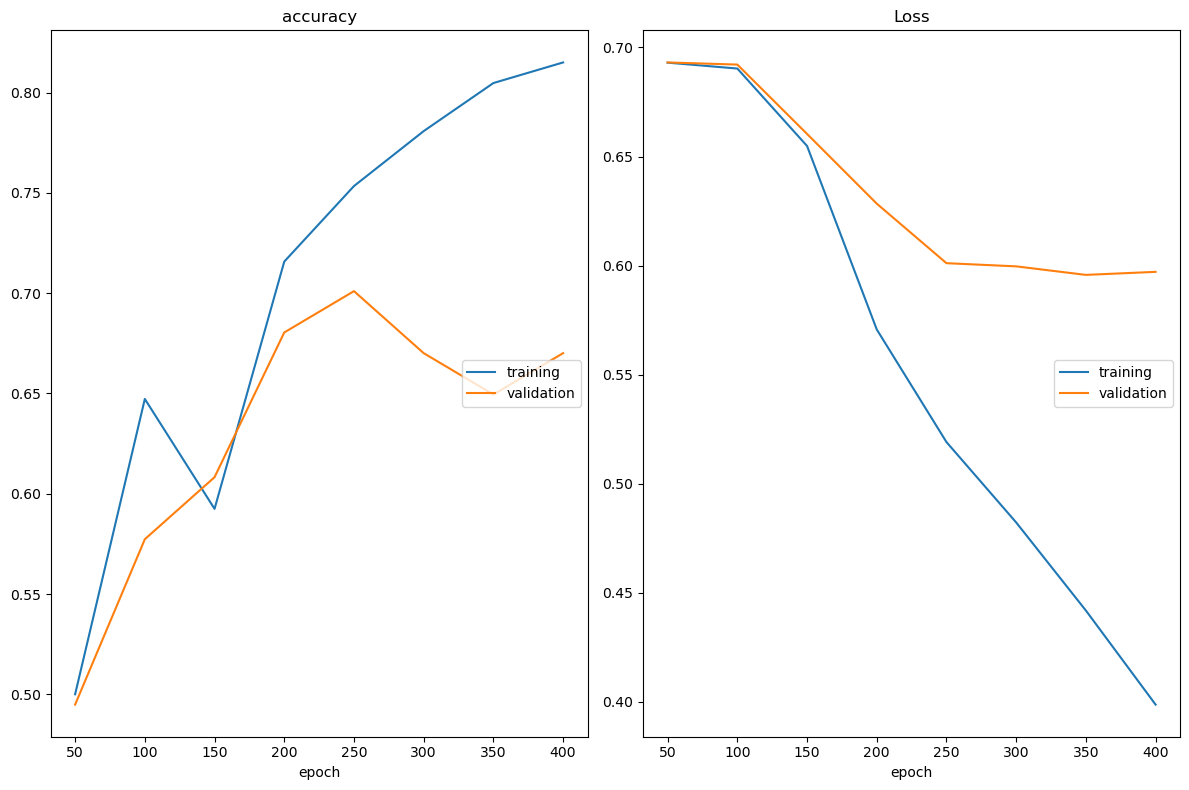

accuracy
	training         	 (min:    0.500, max:    0.815, cur:    0.815)
	validation       	 (min:    0.495, max:    0.701, cur:    0.670)
Loss
	training         	 (min:    0.399, max:    0.693, cur:    0.399)
	validation       	 (min:    0.596, max:    0.693, cur:    0.597)
No significant improvement. Counter: 14
No significant improvement. Counter: 15
No significant improvement. Counter: 16
No significant improvement. Counter: 17
No significant improvement. Counter: 18
No significant improvement. Counter: 19
No significant improvement. Counter: 20
Stopping training


In [78]:
test_model = train_model_with_intervention_1(
    TreeNetwork, 
    patience=20,
    eval_metric="loss", 
    tolerance=torch.Tensor([1e-5]),
    epochs=DEFAULT_EPOCHS
)

In [79]:
def load_checkpoint_model(model_class, folder, name): 
    model = model_class()
    model = torch.nn.DataParallel(model)
    wb_path = os.path.join(folder, name)
    model.load_state_dict(torch.load(wb_path))
    return model 

def validation_inference(model, metrics_X=validation_X, metrics_Y=validation_Y): 
    model.eval()
    with torch.no_grad(): 
        preds_X = model(metrics_X) 
        loss = loss_function(preds_X, metrics_Y)
        accuracy = torcheval.metrics.functional.multiclass_accuracy(torch.argmax(preds_X, dim=-1), metrics_Y)

    print(f"The following metrics are for validation set") 
    print(f"Loss for base model: 0.649")
    print(f"Loss for checkpointed model: {loss:.2f}")
    print(f"Accuracy for base model: 0.610")
    print(f"Accuracy for checkpointed model: {accuracy:.2f}")
    return loss, accuracy 

chkpt_model = load_checkpoint_model(TreeNetwork, "chkpt", "best_model.pth")
chkpt_loss, chkpt_acc = validation_inference(chkpt_model)

The following metrics are for validation set
Loss for base model: 0.649
Loss for checkpointed model: 0.59
Accuracy for base model: 0.610
Accuracy for checkpointed model: 0.66


What are all the different ways you can implement early stopping?

Which way did you implement?

What was your validation accuracy and loss before and after early stopping?

1. Early stopping is basically the idea of stopping the training when the validation starts to plateau or lose. By stopping the training, we can preserve the learned representations of the neural network that are more performant or good at the validation set. There are a few ways that we can implement early stopping. First, we could perform early stopping (on the validation set) using both the validation accuracy metric or the validation loss accuracy. Second, we can also choose *N* numbers of epochs to wait for if the model outputs do not improve before we actually initiate early stopping. Also, I realized that we were given two validation dataset, so we could also look at the validation set for both of the models 
3. I wrote a class function that enables me to try plugging in both loss and validation accuracy to see which one is better for early stopping. The function will allow me to also specify a "patience" value, or the amount of grace periods (i.e., the number of periods we let model continue training even if performance were poorer) as a sort of hyperparameter that I can test out. 
4. By performing an early stopping, we were able to get a validation accuracy of 0.680 with early stopping which is better than the previous validation accuracy without early stopping which 0.645. Additionally, the loss went from 0.635 to 0.61 which also improved significantly. We also were able to checkpoint the model at a good performance and found that the accuracy 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Initialization (5% of the 25%)

Look up what the default weights and biases initialization method is used by PyTorch.

Implement the Kaimeng/He initialization method discussed in the lecture and book.

> Set the random seed to 42 to remove variance in your experiment.


In [104]:
for m, ms in model.named_parameters(): 
    print(m)

conv_0.weight
conv_0.bias
conv_1.weight
conv_1.bias
conv_2.weight
conv_2.bias
conv_3.weight
conv_3.bias
fc_3.weight
fc_3.bias


In [105]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.

torch.manual_seed(42)
def kaiming_initialization(model):
    for m in model.modules():
        if isinstance(m, torch.nn.Conv2d):
            torch.nn.init.kaiming_uniform_(m.weight, mode="fan_in", nonlinearity="relu")
        elif isinstance(m, torch.nn.Linear):
            torch.nn.init.kaiming_uniform_(m.weight, mode="fan_in", nonlinearity="relu")

def check_initialization(model): 
    for name, params in model.named_parameters(): 
        print(f"Name of the parameters: {name}")
        print(f"Mean: {torch.mean(params)}") 
        print(f"Variance: {torch.std(params)}")

model = TreeNetwork()
check_initialization(model)
kaiming_initialization(model)
print(".........................")
check_initialization(model)


Name of the parameters: conv_0.weight
Mean: 0.0004792845866177231
Variance: 0.0677046924829483
Name of the parameters: conv_0.bias
Mean: 0.02056790329515934
Variance: 0.07303332537412643
Name of the parameters: conv_1.weight
Mean: -0.0003651227743830532
Variance: 0.05317346751689911
Name of the parameters: conv_1.bias
Mean: -0.04150330647826195
Variance: 0.0479607880115509
Name of the parameters: conv_2.weight
Mean: -0.00262839044444263
Variance: 0.051282498985528946
Name of the parameters: conv_2.bias
Mean: -0.03347751125693321
Variance: 0.03352808579802513
Name of the parameters: conv_3.weight
Mean: -0.000471537874545902
Variance: 0.050836820155382156
Name of the parameters: conv_3.bias
Mean: -0.017230292782187462
Variance: 0.02403111569583416
Name of the parameters: fc_3.weight
Mean: -0.001005541067570448
Variance: 0.02406846545636654
Name of the parameters: fc_3.bias
Mean: -0.003412568476051092
Variance: 0.0021690414287149906
.........................
Name of the parameters: conv_0

In [108]:
DEFAULT_EPOCHS = 500
    
def train_model_with_intervention_2(
    model_class, 
    epochs=DEFAULT_EPOCHS, 
    learning_rate=1e-4, 
    **kwargs):
    """
    Train a model for a given number of epochs and plot the loss and accuracy for the training and validation sets.
    """
    model = model_class(**kwargs)
    kaiming_initialization(model)
    if torch.cuda.is_available():
        model = model.cuda()

    model = torch.nn.DataParallel(model)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    liveloss = livelossplot.PlotLosses()
    for i in range(epochs):
        model.train()

        optimizer.zero_grad(set_to_none=True)
        prediction = model(train_X)
        loss = loss_function(prediction, train_Y)
        loss.backward()
        optimizer.step()
        
        def get_metrics(metrics_prefix, metrics_X, metrics_Y):
            metrics_prediction = model(metrics_X)
    
            return {
                f"{metrics_prefix}loss": loss_function(metrics_prediction, metrics_Y),
                f"{metrics_prefix}accuracy": torcheval.metrics.functional.multiclass_accuracy(torch.argmax(metrics_prediction, dim=-1), metrics_Y)
            }
                  
        if (i + 1) % 50 == 0:
            liveloss_updates = {}
            with torch.no_grad():
                model.eval()

                liveloss_updates.update(get_metrics("", train_X, train_Y))
                liveloss_updates.update(get_metrics("val_", validation_X, validation_Y))

            liveloss_updates = {k: to_numpy(v) for k, v in liveloss_updates.items()}
            liveloss.update(liveloss_updates,
                            current_step=i+1)
            liveloss.send()

    return model

# We use a fixed seed for reproducibility
torch.manual_seed(42)

test_model = train_model_with_intervention_2(TreeNetwork, epochs=1)
del test_model

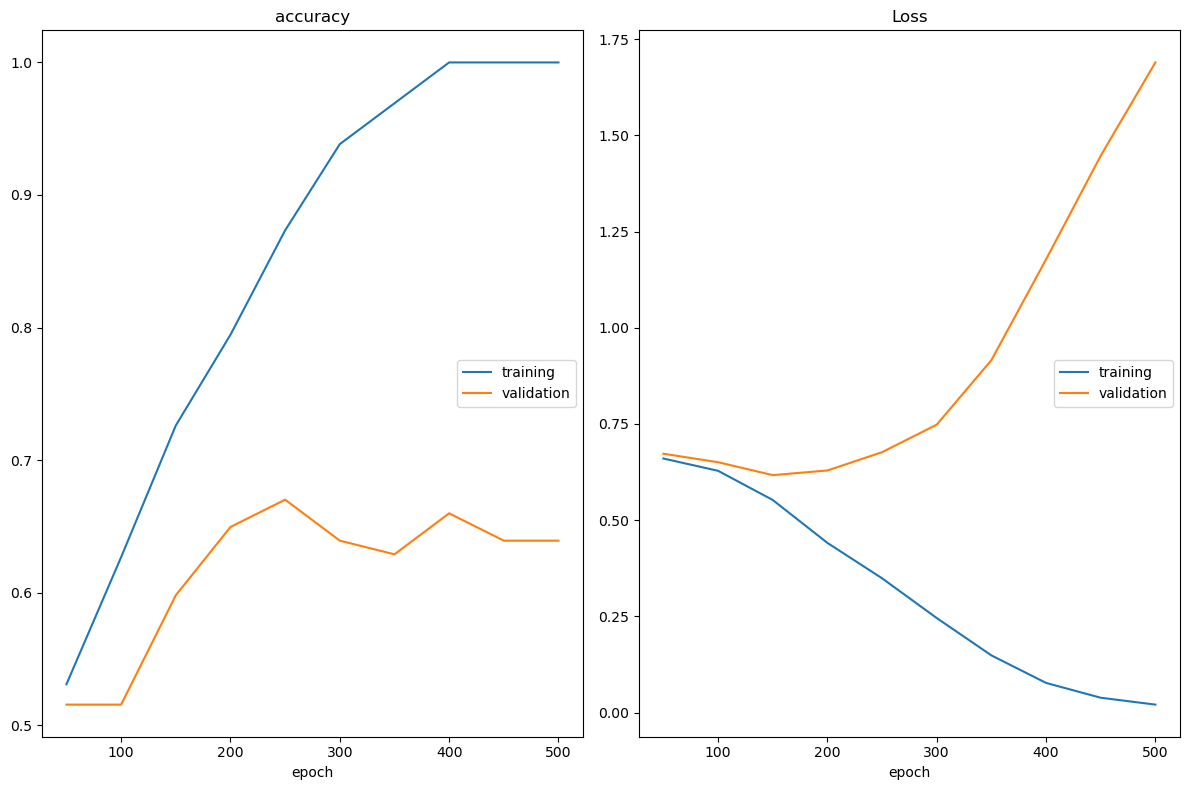

accuracy
	training         	 (min:    0.531, max:    1.000, cur:    1.000)
	validation       	 (min:    0.515, max:    0.670, cur:    0.639)
Loss
	training         	 (min:    0.021, max:    0.660, cur:    0.021)
	validation       	 (min:    0.617, max:    1.690, cur:    1.690)


In [109]:
torch.manual_seed(42)
test_model_with_init = train_model_with_intervention_2(
    TreeNetwork, 
    epochs=DEFAULT_EPOCHS
)

In [90]:
print("Base model loss: 0.610") 
print("Model loss with kaiming uniform init: 1.690") 
print("Base model accuracy: 0.660") 
print("Model accuracy with kaiming uniform init: 0.639") 

Base model loss: 0.610
Model loss with kaiming uniform init: 1.346
Base model accuracy: 0.660
Model accuracy with kaiming uniform init: 0.660


Did the initialization yield any training improvements? If so, why do you think that is?

What wasy your validation trianing and loss with and without your initialization?

I don't think the initialization will yield much training improvements because the **default** Pytorch initialization is the Kaiming uniform distribution. When, I set the seed to be 42, we get around the similar mean and variance during normal model initialization and when I explicitly called the Kaiming initialization function to modify the model parameters in-place. There are a bit of differences which I suspect could be due to the default "a" parameter that Pytorch computes. I did not specify those specifically

The validation for (init) is 0.649 versus (w/o init) is 0.680 and the loss for (init) is 0.578 and the loss (w/o init) is 0.604.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Learning Rate (5% of the 25%)

Sometimes a particular learning rate, or simple fixed learning rate does not give the best results. Experiment with learning rates and learning rate schedules to see if you can get an improvement.

In [8]:
from torch.optim.lr_scheduler import ExponentialLR

In [11]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.   
def train_model_with_intervention_3_lr(
    model_class, 
    epochs=DEFAULT_EPOCHS, 
    learning_rate=1e-4, 
    **kwargs):
    """
    Train a model for a given number of epochs and plot the loss and accuracy for the training and validation sets.
    """
    model = model_class(**kwargs)
    if torch.cuda.is_available():
        model = model.cuda()

    model = torch.nn.DataParallel(model)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = ExponentialLR(optimizer, gamma=0.99)
    liveloss = livelossplot.PlotLosses()

    results = []
    for i in range(epochs):
        model.train()

        optimizer.zero_grad(set_to_none=True)
        prediction = model(train_X)
        loss = loss_function(prediction, train_Y)
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        def get_metrics(metrics_prefix, metrics_X, metrics_Y):
            metrics_prediction = model(metrics_X)
    
            return {
                f"{metrics_prefix}loss": loss_function(metrics_prediction, metrics_Y),
                f"{metrics_prefix}accuracy": torcheval.metrics.functional.multiclass_accuracy(torch.argmax(metrics_prediction, dim=-1), metrics_Y)
            }
                  
        if (i + 1) % 50 == 0:
            liveloss_updates = {}
            with torch.no_grad():
                model.eval()

                liveloss_updates.update(get_metrics("", train_X, train_Y))
                liveloss_updates.update(get_metrics("val_", validation_X, validation_Y))

            liveloss_updates = {k: to_numpy(v) for k, v in liveloss_updates.items()}
            results.append(liveloss_updates) 
            liveloss.update(liveloss_updates,
                            current_step=i+1)
            liveloss.send()

    return model, results

# We use a fixed seed for reproducibility
torch.manual_seed(42)

test_model, results_list  = train_model_with_intervention_3_lr(TreeNetwork, epochs=1)
del test_model

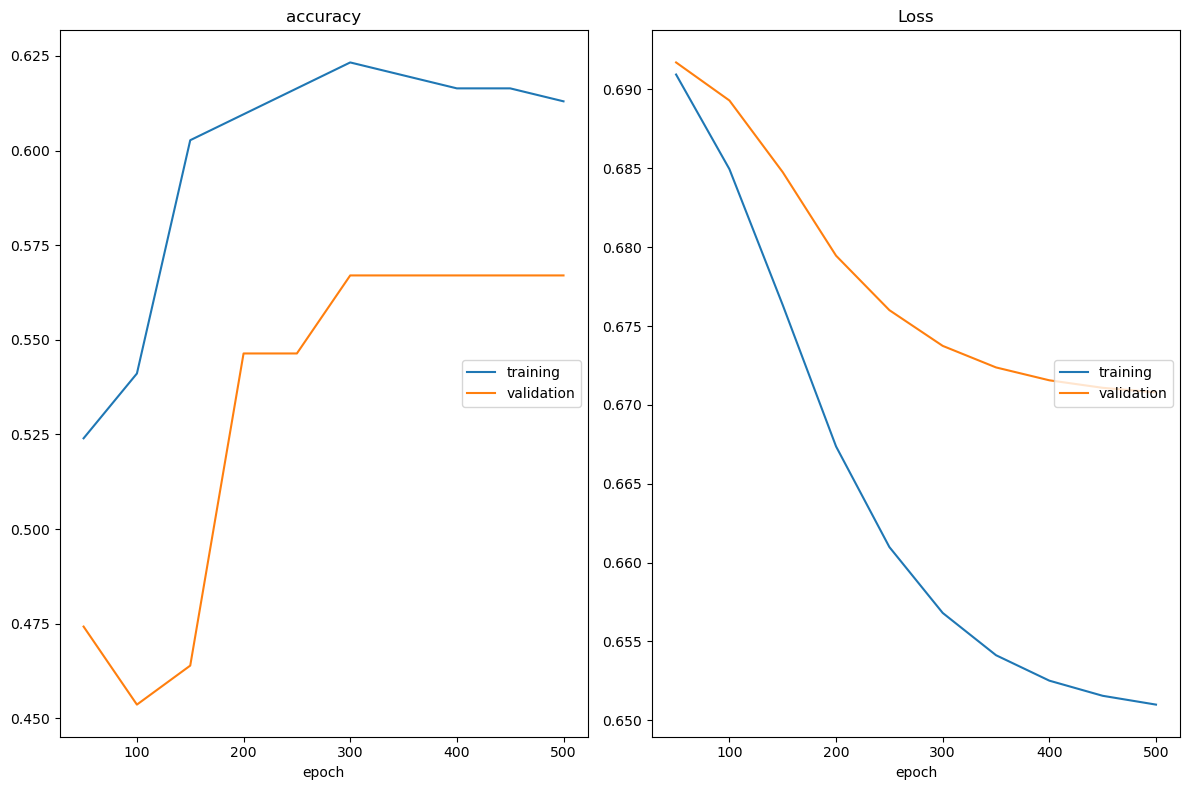

accuracy
	training         	 (min:    0.524, max:    0.623, cur:    0.613)
	validation       	 (min:    0.454, max:    0.567, cur:    0.567)
Loss
	training         	 (min:    0.651, max:    0.691, cur:    0.651)
	validation       	 (min:    0.671, max:    0.692, cur:    0.671)


In [12]:
test_model, results_list_1e2_exp = train_model_with_intervention_3_lr(TreeNetwork, epochs=DEFAULT_EPOCHS, learning_rate=1e-2)
test_model, results_list_1e3_exp = train_model_with_intervention_3_lr(TreeNetwork, epochs=DEFAULT_EPOCHS, learning_rate=1e-3)
test_model, results_list_1e4_exp = train_model_with_intervention_3_lr(TreeNetwork, epochs=DEFAULT_EPOCHS, learning_rate=1e-4)


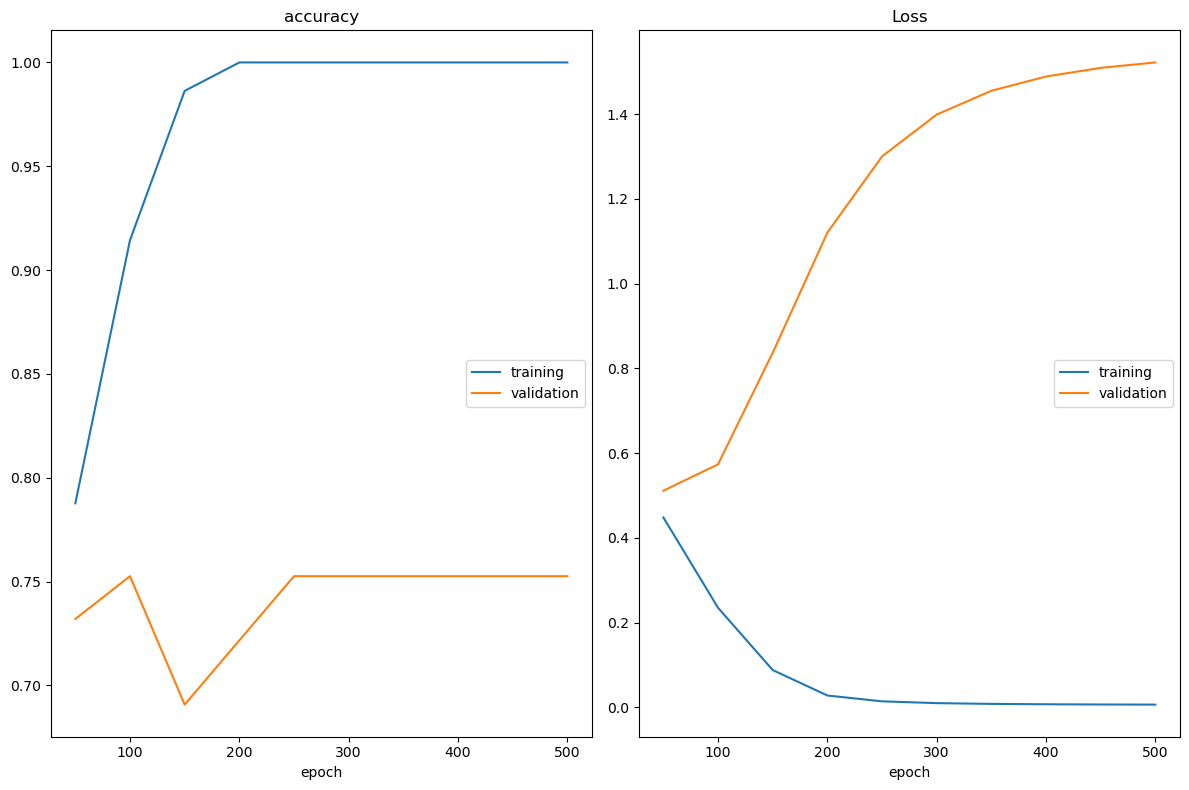

accuracy
	training         	 (min:    0.788, max:    1.000, cur:    1.000)
	validation       	 (min:    0.691, max:    0.753, cur:    0.753)
Loss
	training         	 (min:    0.006, max:    0.448, cur:    0.006)
	validation       	 (min:    0.511, max:    1.522, cur:    1.522)


In [20]:
test_model, results_list_1e3o1_exp = train_model_with_intervention_3_lr(TreeNetwork, epochs=DEFAULT_EPOCHS, learning_rate=1.5*1e-3)
test_model, results_list_1e3o2_exp = train_model_with_intervention_3_lr(TreeNetwork, epochs=DEFAULT_EPOCHS, learning_rate=2*1e-3)
test_model, results_list_1e3o3_exp = train_model_with_intervention_3_lr(TreeNetwork, epochs=DEFAULT_EPOCHS, learning_rate=5*1e-3)

In [23]:
def parse_results_for_best_val_results(results_list, m="accuracy"):
    res = min(results_list, key=lambda x: x['val_loss']) if m == "loss" else max(results_list, key=lambda x: x['val_accuracy']) 
    print("Loss:", res['val_loss'], "Accuracy", res['val_accuracy'])
    return res

print("Base model loss: 0.610")
print("Base model accuracy: 0.660")

print("LR=1e-2")
r=parse_results_for_best_val_results(results_list_1e2_exp)
print("LR=1e-3")
y=parse_results_for_best_val_results(results_list_1e3_exp)
print("LR=1e-4")
z=parse_results_for_best_val_results(results_list_1e4_exp)

print("Since, LR=1e-3 performed pretty well with exponential decay scheduler")
print("LR=0.0015")
z=parse_results_for_best_val_results(results_list_1e3o1_exp)
print("LR=0.002")
z=parse_results_for_best_val_results(results_list_1e3o2_exp)
print("LR=0.005")
z=parse_results_for_best_val_results(results_list_1e3o3_exp)

Base model loss: 0.610
Base model accuracy: 0.660
LR=1e-2
Loss: 0.6931464 Accuracy 0.5051546
LR=1e-3
Loss: 0.59657973 Accuracy 0.82474226
LR=1e-4
Loss: 0.6737403 Accuracy 0.5670103
Since, LR=1e-3 performed pretty well with exponential decay scheduler
LR=0.0015
Loss: 0.542983 Accuracy 0.78350514
LR=0.002
Loss: 0.5423106 Accuracy 0.83505154
LR=0.005
Loss: 0.573596 Accuracy 0.7525773


Did learning rate help? If so, why do you think that is?

What's the best validation accuracy and loss you could achieve compared to the baseline?

The learning rate did help us improve on both the loss and accuracy. The loss from the baseline went from 0.610 to 0.542 and from accuracy of 0.66 to 0.83. These are pretty significant performance improvements from the baseline. I think this is because the large learning rate allow the model to bounce around and out of regions w/ local minima. The exponential decay for the loss function then helps the model dynamically reduce the learning rate continuously to slowly descend down the minima and not ping pong back and forth. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Regularization (5% of the 25%)

Try different regularization methods to see which one or ones give the best results.

In [25]:
class TreeNetworkD(torch.nn.Module):
    def __init__(self, dropout_rate):
        super().__init__()

        self.conv_0 = torch.nn.Conv2d(in_channels=3, out_channels=5, kernel_size=5, stride=2, device=device)
        self.dropout_0 = torch.nn.Dropout(p=dropout_rate)
        self.conv_1 = torch.nn.Conv2d(in_channels=5, out_channels=5, kernel_size=5, stride=2, device=device)
        self.dropout_1 = torch.nn.Dropout(p=dropout_rate)
        self.conv_2 = torch.nn.Conv2d(in_channels=5, out_channels=5, kernel_size=5, stride=2, device=device)
        self.dropout_2 = torch.nn.Dropout(p=dropout_rate)
        self.conv_3 = torch.nn.Conv2d(in_channels=5, out_channels=5, kernel_size=5, stride=2, device=device)
        self.dropout_3 = torch.nn.Dropout(p=dropout_rate)
        self.fc_3 = torch.nn.Linear(585, 2)

        self.relu = torch.nn.ReLU()

    def forward(self, X):

        X = self.conv_0(X)
        X = self.dropout_0(X)
        X = self.relu(X)

        X = self.conv_1(X)
        X = self.dropout_1(X)
        X = self.relu(X)

        X = self.conv_2(X)
        X = self.dropout_2(X)
        X = self.relu(X)

        X = self.conv_3(X)
        X = self.dropout_3(X)
        X = self.relu(X)

        # flatten channels and image dimensions
        X = X.reshape(X.shape[:-3] + (-1,))

        X = self.fc_3(X)

        return X

test_model = TreeNetworkD(dropout_rate=0.25).to(device)
test_output = test_model(train_X[:5,:,:,:])
assert test_output.shape == (5, 2)
del test_output

In [27]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.

## We can add explicit regulation via an L2 penalty (which adds a penalty term that is lambda * summed square of all the weights) 

DEFAULT_EPOCHS = 500
    
def train_model_with_intervention_regularization(
    model_class,
    dropout_rate,
    weight_decay=0, 
    epochs=DEFAULT_EPOCHS,
    learning_rate=1e-4,
    **kwargs):
    """
    Train a model for a given number of epochs and plot the loss and accuracy for the training and validation sets.
    """
    model = model_class(dropout_rate=dropout_rate, **kwargs)
    if torch.cuda.is_available():
        model = model.cuda()

    model = torch.nn.DataParallel(model)
   
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    liveloss = livelossplot.PlotLosses()
    
    results = []
    for i in range(epochs):
        model.train()

        optimizer.zero_grad(set_to_none=True)
        prediction = model(train_X)
        loss = loss_function(prediction, train_Y)
        loss.backward()
        optimizer.step()
        
        def get_metrics(metrics_prefix, metrics_X, metrics_Y):
            metrics_prediction = model(metrics_X)
    
            return {
                f"{metrics_prefix}loss": loss_function(metrics_prediction, metrics_Y),
                f"{metrics_prefix}accuracy": torcheval.metrics.functional.multiclass_accuracy(torch.argmax(metrics_prediction, dim=-1), metrics_Y)
            }

        if (i + 1) % 50 == 0:
            liveloss_updates = {}
            with torch.no_grad():
                model.eval()

                liveloss_updates.update(get_metrics("", train_X, train_Y))
                liveloss_updates.update(get_metrics("val_", validation_X, validation_Y))

            liveloss_updates = {k: to_numpy(v) for k, v in liveloss_updates.items()}
            results.append(liveloss_updates)
            liveloss.update(liveloss_updates,
                            current_step=i+1)
            liveloss.send()
           
    return model, results

# We use a fixed seed for reproducibility
torch.manual_seed(42)

test_model, res = train_model_with_intervention_regularization(
    TreeNetworkD, 
    dropout_rate=0.25,
    epochs=1)
del test_model
del res 

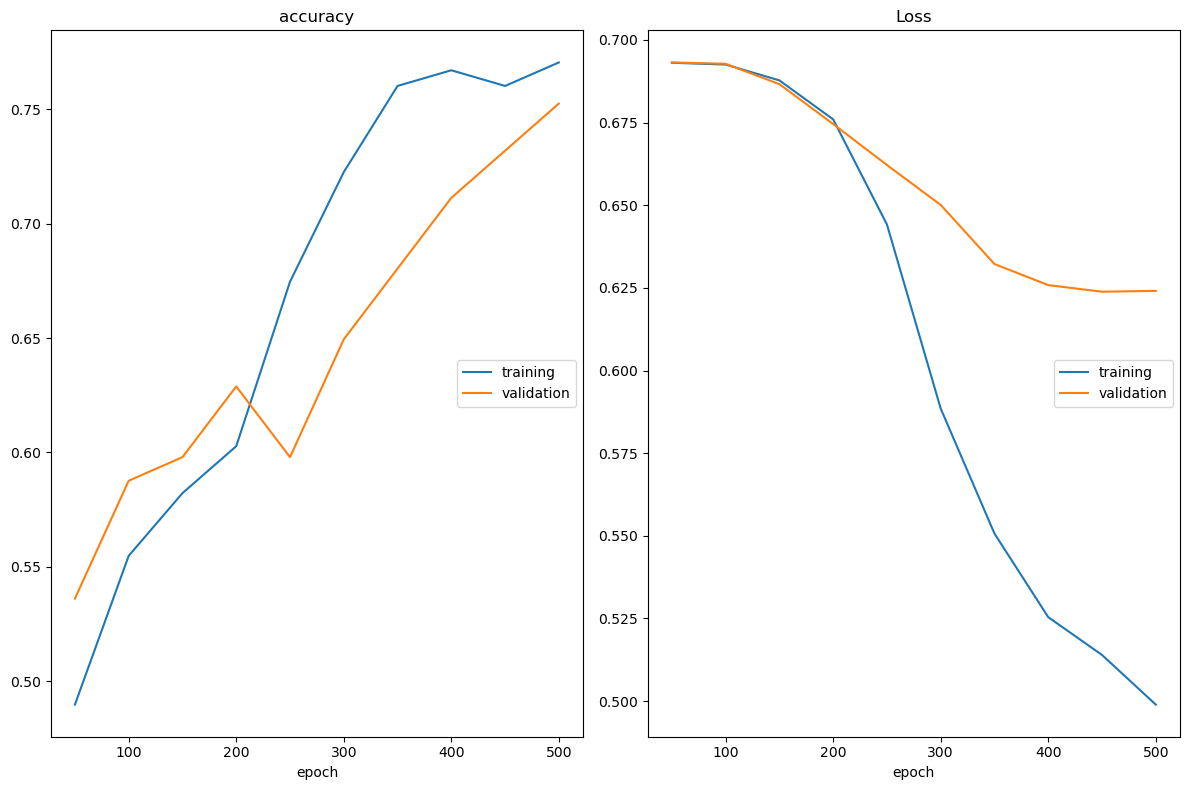

accuracy
	training         	 (min:    0.490, max:    0.771, cur:    0.771)
	validation       	 (min:    0.536, max:    0.753, cur:    0.753)
Loss
	training         	 (min:    0.499, max:    0.693, cur:    0.499)
	validation       	 (min:    0.624, max:    0.693, cur:    0.624)


In [29]:
torch.manual_seed(42)
model_w_reg_1, results_p020  = train_model_with_intervention_regularization(
                                            TreeNetworkD, 
                                            dropout_rate=0.2,
                                            epochs=DEFAULT_EPOCHS)
model_w_reg_1, results_p030  = train_model_with_intervention_regularization(
                                            TreeNetworkD, 
                                            dropout_rate=0.3,
                                            epochs=DEFAULT_EPOCHS)
model_w_reg_1, results_p040  = train_model_with_intervention_regularization(
                                            TreeNetworkD, 
                                            dropout_rate=0.4,
                                            epochs=DEFAULT_EPOCHS)
model_w_reg_1, results_p050  = train_model_with_intervention_regularization(
                                            TreeNetworkD, 
                                            dropout_rate=0.5,
                                            epochs=DEFAULT_EPOCHS)

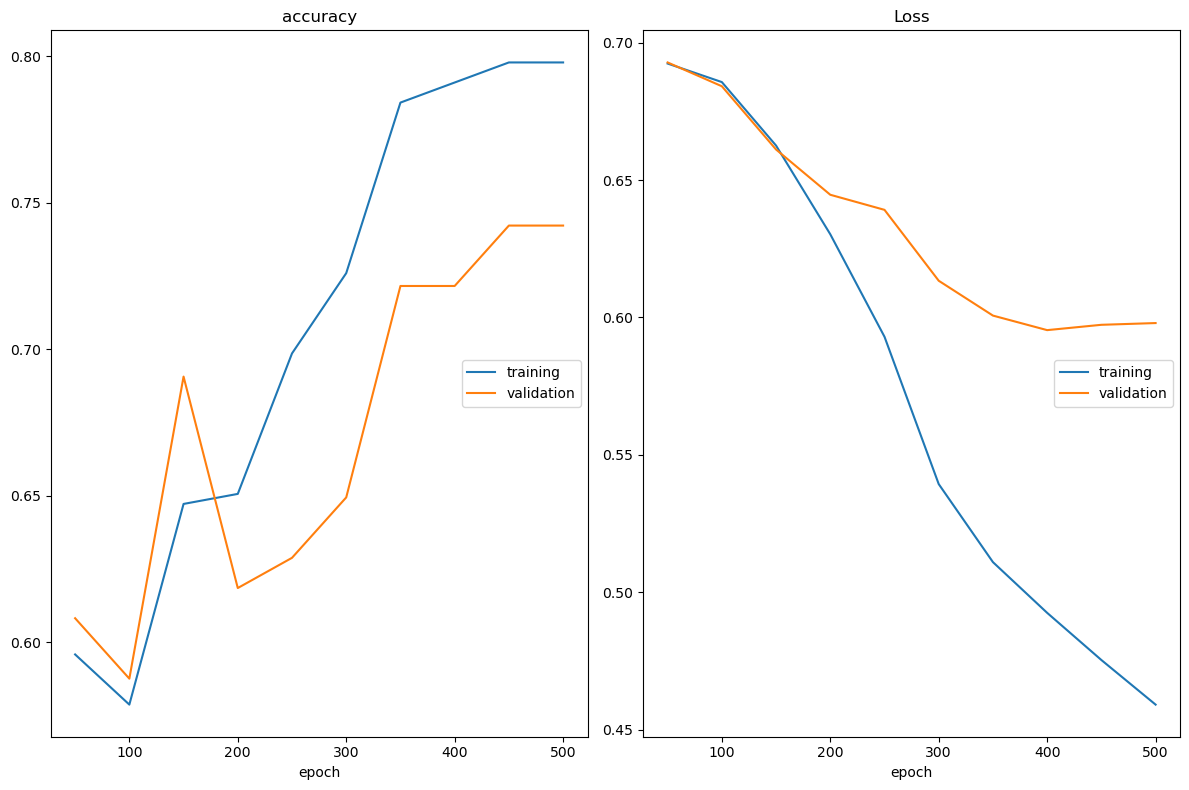

accuracy
	training         	 (min:    0.579, max:    0.798, cur:    0.798)
	validation       	 (min:    0.588, max:    0.742, cur:    0.742)
Loss
	training         	 (min:    0.459, max:    0.692, cur:    0.459)
	validation       	 (min:    0.595, max:    0.693, cur:    0.598)


In [37]:
torch.manual_seed(42)

model_w_reg_1, results_p020_w00003  = train_model_with_intervention_regularization(
                                            TreeNetworkD, 
                                            dropout_rate=0.2,
                                            weight_decay=3*1e-4,
                                            epochs=DEFAULT_EPOCHS)
model_w_reg_1, results_p020_w00005  = train_model_with_intervention_regularization(
                                            TreeNetworkD, 
                                            dropout_rate=0.2,
                                            weight_decay=5*1e-4,
                                            epochs=DEFAULT_EPOCHS)
model_w_reg_1, results_p030_w00001  = train_model_with_intervention_regularization(
                                            TreeNetworkD, 
                                            dropout_rate=0.3,
                                            weight_decay=1e-4,
                                            epochs=DEFAULT_EPOCHS)
model_w_reg_1, results_p030_w000001  = train_model_with_intervention_regularization(
                                            TreeNetworkD, 
                                            dropout_rate=0.3,
                                            weight_decay=1e-5,
                                            epochs=DEFAULT_EPOCHS)


In [39]:
print("==========================")
print("Base model loss: 0.610")
print("Base model accuracy: 0.660")

print("Dropout Rate: p=0.2")
r=parse_results_for_best_val_results(results_p020)
print("Dropout Rate: p=0.3")
r=parse_results_for_best_val_results(results_p030)
print("Dropout Rate: p=0.4")
r=parse_results_for_best_val_results(results_p040)
print("Dropout Rate: p=0.5")
r=parse_results_for_best_val_results(results_p050)

print("Dropout Rate: p=0.2, Weight Decay: weight_decay=3*1e-4")
r=parse_results_for_best_val_results(results_p020_w00003)
print("Dropout Rate: p=0.2, Weight Decay: weight_decay=5*1e-4")
r=parse_results_for_best_val_results(results_p020_w00005)
print("Dropout Rate: p=0.3, Weight Decay: weight_decay=1e-4")
r=parse_results_for_best_val_results(results_p030_w00001)
print("Dropout Rate: p=0.3, Weight Decay: weight_decay=1e-5")
r=parse_results_for_best_val_results(results_p030_w000001)

Base model loss: 0.610
Base model accuracy: 0.660
Dropout Rate: p=0.2
Loss: 0.58404833 Accuracy 0.6701031
Dropout Rate: p=0.3
Loss: 0.56801355 Accuracy 0.7938144
Dropout Rate: p=0.4
Loss: 0.61785257 Accuracy 0.7010309
Dropout Rate: p=0.5
Loss: 0.62408626 Accuracy 0.7525773
Dropout Rate: p=0.2, Weight Decay: weight_decay=3*1e-4
Loss: 0.5792371 Accuracy 0.73195875
Dropout Rate: p=0.2, Weight Decay: weight_decay=5*1e-4
Loss: 0.566706 Accuracy 0.77319586
Dropout Rate: p=0.3, Weight Decay: weight_decay=1e-4
Loss: 0.57891124 Accuracy 0.6494845
Dropout Rate: p=0.3, Weight Decay: weight_decay=1e-5
Loss: 0.59732443 Accuracy 0.742268


What are different types of regularization methods?

Which ones did you try?

Which worked the best and why do you think that is?

What is the improvement validation accuracy and loss over baseline?

1. There are different types of regularization methods. There are explicit regularization methods where we can add a penalty term to the loss function. For instance, a common explicit regularization method is L2 regularization where we add a penalty that includes lambda times the sum squared of all the parameters. This discourages models from having large weights, which could help with overfitting since large weights are more sensitive to small changes in inputs. Another family of regularization methods include implicit regularization which modifies the architecture or training process and thereby 'indirectly' affecting how the model learns the weights. Explicit regularization directly modifies the loss function. One implicit regularization method is dropout, where we clamp a few of the intermediate outputs (i.e., activations). This method enables the model to not rely on a few subset of neurons.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Data Augmentation (5% of the 25%)

This is a relatively small dataset. In such cases data augmentation may help with generalization.

Try different data augmentations and report the results and improvements.

In [82]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=20, translate=(0.2, 0.2), shear=10),
    transforms.ToTensor(),
])

# DO NOT CHANGE THIS CELL

image_width = 256

def load_data_set_2(data_set_name):
    labels = pd.read_csv(f"{data_dir}/{data_set_name}.tsv", sep="\t")

    file_names = []
    images = []
    targets = []
    for i in range(labels.shape[0]):
        row = labels.iloc[i]
        row_transformed_name=f"{row}_transformed"
        try:
            image = imageio.imread(f"{data_dir}/images{image_width}/{row['filename']}")[...]
        except:
            print("SKIPPING ", row['filename'], "MISSING")
            continue

        if image.shape[0] != image.shape[1] * 3 // 4:
            print("SKIPPING ", row['filename'], image.shape)
            continue

        # convert from 0-255 to 0.0-1.0
        image = image / 255
        pil_image = Image.fromarray((image * 255).astype("uint8"))

        # Apply transformations
        transformed_image = transform(pil_image).to(dtype=torch.float32, device=device)  # [C,H,W] tensor

        # prepend axis with length one
        # image = image.reshape(1, *image.shape)
        image = torch.tensor(image, device=device, dtype=torch.float32)
        # permute image dimensions to put color channel first
        image = torch.permute(image, [2, 0, 1])

        file_names.append(row['filename'])
        images.append(image)
        targets.append(row["target"])
        file_names.append(row_transformed_name)
        images.append(transformed_image)
        targets.append(row["target"]) 

    images = torch.stack(images)
    targets = torch.tensor(targets, device=device, dtype=torch.float32)
    targets = targets.long()

    return (file_names, images, targets)

train_data_set_aug = load_data_set_2("train")
for t in train_data_set[1:]:
    print("TRAIN", t.shape, t.dtype, t.device)
(train_file_names_aug, train_X_aug, train_Y_aug) = train_data_set_aug

validation_data_set_aug = load_data_set_2("validation")
for t in validation_data_set[1:]:
    print("VALIDATION", t.shape, t.dtype, t.device)
(validation_file_names_aug, validation_X_aug, validation_Y_aug) = validation_data_set_aug

validation2_data_set_aug = load_data_set_2("validation2")
for t in validation2_data_set[1:]:
    print("VALIDATION2", t.shape, t.dtype, t.device)
(validation2_file_names_aug, validation2_X_aug, validation2_Y_aug) = validation2_data_set_aug

TRAIN torch.Size([292, 3, 192, 256]) torch.float32 cuda:0
TRAIN torch.Size([292]) torch.int64 cuda:0
VALIDATION torch.Size([97, 3, 192, 256]) torch.float32 cuda:0
VALIDATION torch.Size([97]) torch.int64 cuda:0
SKIPPING  IMG_1585.png (256, 192, 3)
VALIDATION2 torch.Size([108, 3, 192, 256]) torch.float32 cuda:0
VALIDATION2 torch.Size([108]) torch.int64 cuda:0


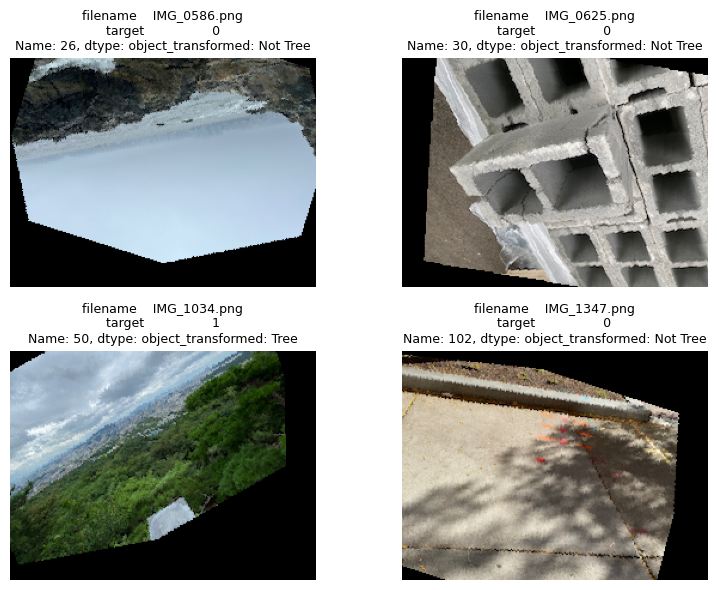

In [83]:
idx = torch.randperm(train_X.shape[0])[:4]
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

label_names = {0: "Not Tree", 1: "Tree"}

for ax, i in zip(axes.flatten(), idx):
    ax.imshow(to_numpy(torch.permute(train_X_aug[i, :, :, :], (1, 2, 0))))
    label = label_names.get(int(train_Y_aug[i]), str(int(train_Y_aug[i])))
    ax.set_title(f"{train_file_names_aug[int(i)]}: {label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()

In [85]:
DEFAULT_EPOCHS = 500

def train_model_with_aug(model_class, epochs=DEFAULT_EPOCHS, learning_rate=1e-4, **kwargs):
    """
    Train a model for a given number of epochs and plot the loss and accuracy for the training and validation sets.
    """
    model = model_class(**kwargs)
    if torch.cuda.is_available():
        model = model.cuda()

    model = torch.nn.DataParallel(model)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    liveloss = livelossplot.PlotLosses()
    for i in range(epochs):
        model.train()

        optimizer.zero_grad(set_to_none=True)
        prediction = model(train_X_aug)
        loss = loss_function(prediction, train_Y_aug)
        loss.backward()
        optimizer.step()

        if (i + 1) % 50 == 0:
            liveloss_updates = {}
            with torch.no_grad():
                model.eval()

                def get_metrics(metrics_prefix, metrics_X, metrics_Y):
                    metrics_prediction = model(metrics_X)

                    return {
                        f"{metrics_prefix}loss": loss_function(metrics_prediction, metrics_Y),
                        f"{metrics_prefix}accuracy": torcheval.metrics.functional.multiclass_accuracy(torch.argmax(metrics_prediction, dim=-1), metrics_Y)
                    }
                
                liveloss_updates.update(get_metrics("", train_X_aug, train_Y_aug))
                liveloss_updates.update(get_metrics("val_", validation_X_aug, validation_Y_aug))

            liveloss_updates = {k: to_numpy(v) for k, v in liveloss_updates.items()}
            liveloss.update(liveloss_updates,
                            current_step=i+1)
            liveloss.send()

    return model

# We use a fixed seed for reproducibility
torch.manual_seed(42)

test_model = train_model(TreeNetwork, epochs=1)
del test_model

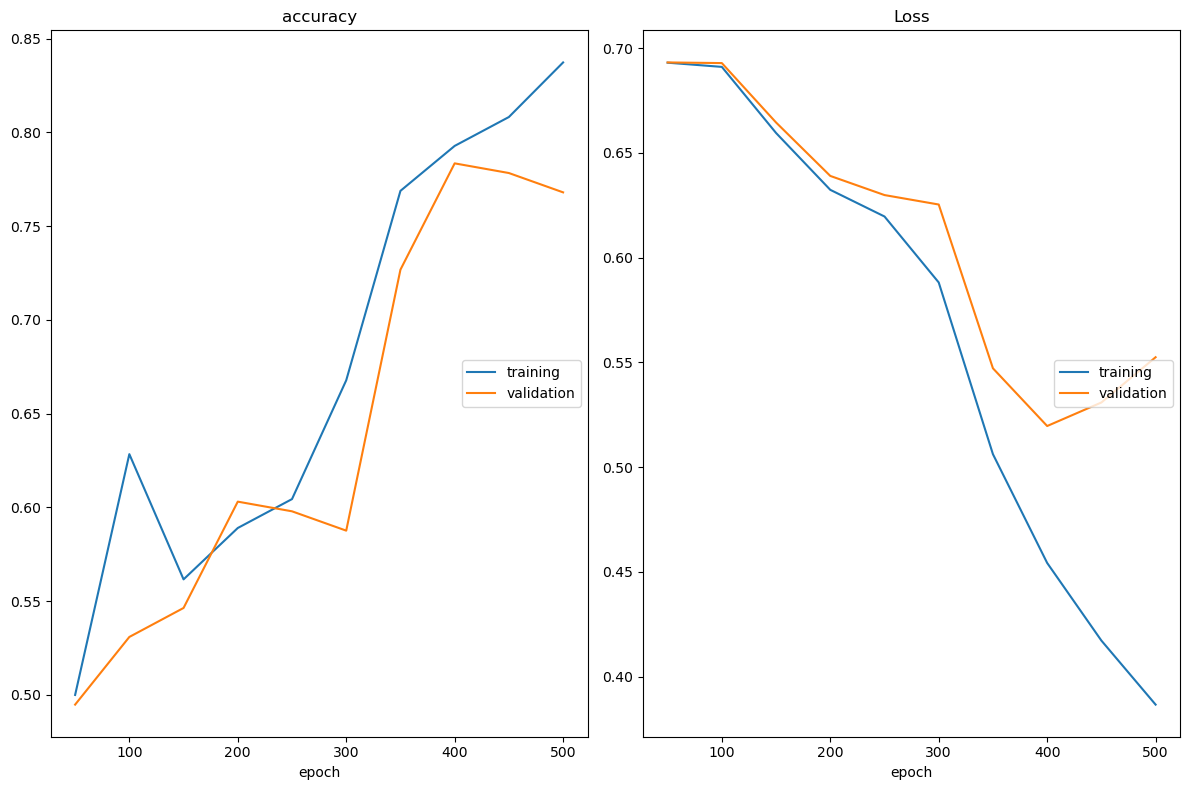

accuracy
	training         	 (min:    0.500, max:    0.837, cur:    0.837)
	validation       	 (min:    0.495, max:    0.784, cur:    0.768)
Loss
	training         	 (min:    0.387, max:    0.693, cur:    0.387)
	validation       	 (min:    0.520, max:    0.693, cur:    0.552)


In [86]:
model_res = train_model_with_aug(
    TreeNetwork
)

What data augmentation methods did you use?

How much of an improvement did you get over the baseline validation accuracy and loss?

_Type your answer here, replacing this text._
I used data augmentation techniques that transformed 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Training All Combinations (30%)

Take the best configuration of each of the five training modifications and apply them all to see what overall improvement you can get.

Note that it is possible that some improvements negatively impact other improvements. If you want to be truly rigorous you would implement a training function that takes arguments for each of the improvements so you can sweep through all the combinations. In fact there are experiment tracking tools that help you do this like [Weights and Bias Sweeps](https://docs.wandb.ai/models/sweeps). It is free for students by the way.

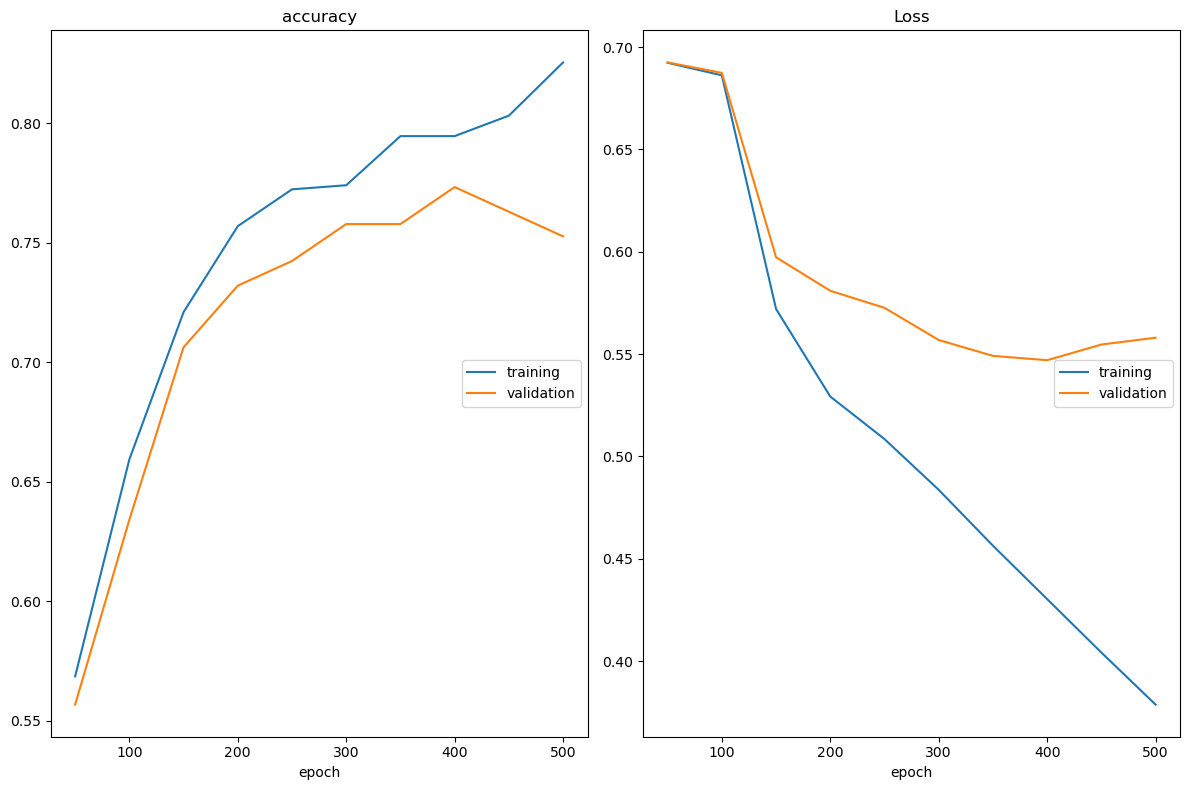

accuracy
	training         	 (min:    0.568, max:    0.825, cur:    0.825)
	validation       	 (min:    0.557, max:    0.773, cur:    0.753)
Loss
	training         	 (min:    0.379, max:    0.692, cur:    0.379)
	validation       	 (min:    0.547, max:    0.692, cur:    0.558)


In [91]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.

def train_model_with_combo(
    model_class=TreeNetworkD,
    patience=15, 
    eval_metric="loss", 
    tolerance=torch.Tensor([1e-4]), 
    dropout_rate=0, 
    epochs=DEFAULT_EPOCHS, 
    weight_decay=0, 
    learning_rate=1e-4, 
    **kwargs
):
    """
    Train a model for a given number of epochs and plot the loss and accuracy for the training and validation sets.
    """
    model = model_class(dropout_rate=dropout_rate)
    stopper = EarlyStopping(
        patience=patience,
        metric=eval_metric, 
        tolerance=tolerance
    )
    if torch.cuda.is_available():
        model = model.cuda()

    model = torch.nn.DataParallel(model)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    liveloss = livelossplot.PlotLosses()
    for i in range(epochs):
        model.train()

        optimizer.zero_grad(set_to_none=True)
        prediction = model(train_X_aug)
        loss = loss_function(prediction, train_Y_aug)
        loss.backward()
        optimizer.step()
        
        with torch.no_grad(): 
            model.eval()
            val_dict = get_metrics("", validation_X, validation_Y)
            val_metric = val_dict[eval_metric]
            should_stop = stopper.check_metrics(current_metric=val_metric, model=model)
            if should_stop: 
                break 

        if (i + 1) % 50 == 0:
            liveloss_updates = {}
            with torch.no_grad():
                model.eval()

                def get_metrics(metrics_prefix, metrics_X, metrics_Y):
                    metrics_prediction = model(metrics_X)

                    return {
                        f"{metrics_prefix}loss": loss_function(metrics_prediction, metrics_Y),
                        f"{metrics_prefix}accuracy": torcheval.metrics.functional.multiclass_accuracy(torch.argmax(metrics_prediction, dim=-1), metrics_Y)
                    }
                
                liveloss_updates.update(get_metrics("", train_X_aug, train_Y_aug))
                liveloss_updates.update(get_metrics("val_", validation_X_aug, validation_Y_aug))

            liveloss_updates = {k: to_numpy(v) for k, v in liveloss_updates.items()}
            liveloss.update(liveloss_updates,
                            current_step=i+1)
            liveloss.send()

    return model
    
torch.manual_seed(42)

test_model = train_model_with_combo(
    
)
del test_model


What is your validation accuracy and loss compared to the baseline?

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Validate Set 2 (10%)

Test your best model again with the validation2 data.

Use your existing models trained and do not retrain them using the validation2 data.

In [ ]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.

...

Report you accuracy and loss of validation set 2 vs validation set 1.

Any surprises? If so, can you explain why?

_Type your answer here, replacing this text._

<!-- END QUESTION -->

If your new validation results are poor, you may go back and refine your training improvements, but avoid using validation2 when you do so.

<!-- BEGIN QUESTION -->

## Save Best Model for Auto-Grader Evaluation (30%)

Use `torch.save` to save your best performing model as "best.pt".
Check the auto-grader results as soon as possible to confirm that it can load your model.

Hint: The auto-grader will check this model's accuracy on a withheld test set.
Review your results above and tweak your improvements as you feel appropriate.
But beware, overfitting on the visible data sets will likely lead to poor performance on the withheld test set.

In [ ]:
# Save your best model with torch.save as "best.pt"
# replace `base_model` with the name of your best model

# if model may be wrapped in DataParallel
to_save = base_model.module.state_dict() if hasattr(base_model, "module") else base_model.state_dict()
torch.save(to_save, "best.pt")


<!-- END QUESTION -->

